##**Customer Segmentation of data using Unsupervised Machine Learning**

**Objective**

To segment customers into distinct groups based on their behavior, preferences, and demographics using data analysis and machine learning techniques.

**Problem Statement**

Businesses have diverse customers with different needs and behaviors. The goal is to group customers into meaningful segments to enable targeted marketing, personalized services, and improved customer engagement.

This is an unsupervised learning problem.

###**Step 1: Import required Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


pandas → Data handling & manipulation

matplotlib.pyplot → Data visualization (plots, graphs)

StandardScaler → Feature scaling (standardization)

KMeans → Clustering algorithm

###**Step 2: Load the Dataset**



The dataset contains customer demographic and behavioral information (such as age, gender, income, and spending behavior) used to group customers into similar segments for targeted analysis and marketing.


In [13]:
file_path = "/content/customer_segmentation_data.csv"
data = pd.read_csv(file_path)

print(data.head())



   id  age  gender  income  spending_score  membership_years  \
0   1   38  Female   99342              90                 3   
1   2   21  Female   78852              60                 2   
2   3   60  Female  126573              30                 2   
3   4   40   Other   47099              74                 9   
4   5   65  Female  140621              21                 3   

   purchase_frequency preferred_category  last_purchase_amount  
0                  24          Groceries                113.53  
1                  42             Sports                 41.93  
2                  28           Clothing                424.36  
3                   5      Home & Garden                991.93  
4                  25        Electronics                347.08  


In [12]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1000 non-null   int64  
 1   age                   1000 non-null   int64  
 2   gender                1000 non-null   object 
 3   income                1000 non-null   int64  
 4   spending_score        1000 non-null   int64  
 5   membership_years      1000 non-null   int64  
 6   purchase_frequency    1000 non-null   int64  
 7   preferred_category    1000 non-null   object 
 8   last_purchase_amount  1000 non-null   float64
 9   Cluster               1000 non-null   int32  
dtypes: float64(1), int32(1), int64(6), object(2)
memory usage: 74.3+ KB
None


###**Step 3: Select Features for Segmentation**

Here we will choose 2 features:

1. Annual_Income (income)

2. Spending_Score (spending_score)


In [5]:
X = data[['income', 'spending_score']]


###**Step 4: Scale the Features**

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



###**Step 5: Find Optimal Number of Clusters using Elbow Method**

**Elbow Method**

The Elbow Method is a technique used to determine the optimal number of clusters (K) in K-Means clustering.

**Why is it needed?**

K-Means requires the value of K (number of clusters) to be specified in advance. The Elbow Method helps choose a value of K that provides good clustering without unnecessary complexity.

**How does it work?**

* Run the K-Means algorithm for different values of K (e.g., K = 1 to 10).

* For each K, calculate the Within-Cluster Sum of Squares (WCSS).

* Plot a graph of Number of Clusters (K) on the x-axis and WCSS on the y-axis.

**What is WCSS?**

WCSS measures the total squared distance between each data point and the centroid of the cluster it belongs to.
Lower WCSS indicates more compact and well-formed clusters.

**Elbow Point**

* As K increases, WCSS decreases because data points are divided into smaller clusters.

* Initially, WCSS drops sharply.

* After a certain value of K, the decrease in WCSS becomes slow and gradual.

* This point where the curve bends and forms an “elbow” is considered the optimal number of clusters.

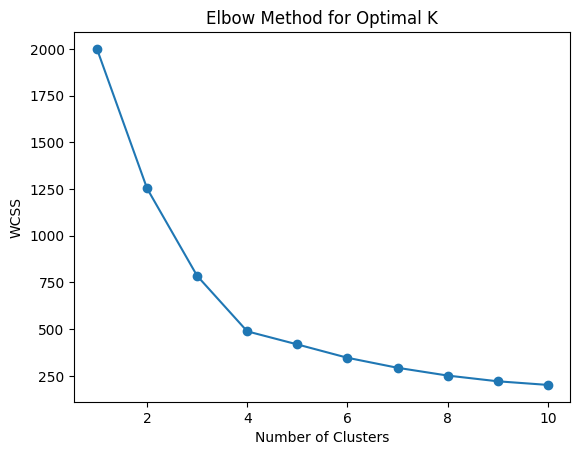

In [7]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()


###Choose K where the curve bends
Here the curve bends at 4

Hence k=4

###**Step 6: Apply K-Means Clustering (using k = 4)**

In [16]:
kmeans = KMeans(n_clusters=4, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)


###**Step 7: Visualize Customer Segments**

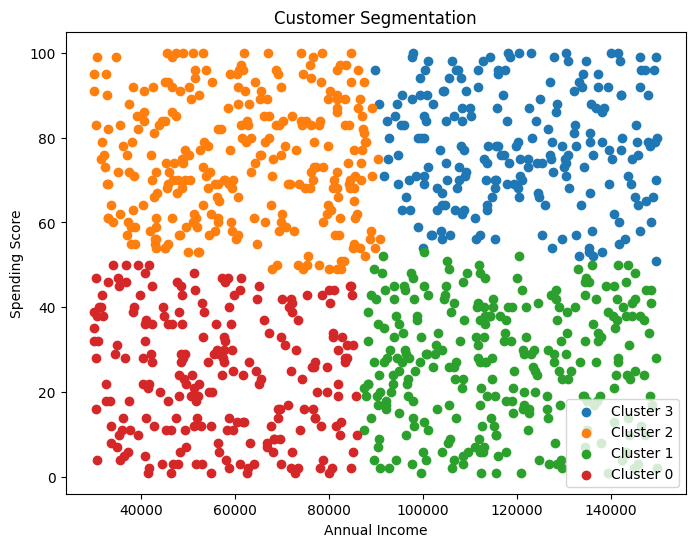

In [10]:
plt.figure(figsize=(8,6))

for cluster in data['Cluster'].unique():
    plt.scatter(
        data[data['Cluster'] == cluster]['income'],
        data[data['Cluster'] == cluster]['spending_score'],
        label=f'Cluster {cluster}'
    )

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")
plt.legend()
plt.show()


**Example Business Interpretation**

**Cluster 0:** Low income, low spending → Budget customers

**Cluster 1:** Low income, high spending → Impulsive buyers

**Cluster 2:** High income, low spending → Careful customers

**Cluster 3:** High income, high spending → Premium customers

Silhouette Score (Most Common)

What it measures:
How well each customer fits within its cluster compared to other clusters.

Range:

0-1 → well-clustered

0 → overlapping clusters

−1 → wrong clustering



In [18]:

from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, data['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.4189735063734962


Davies–Bouldin Index

What it measures:
Average similarity between clusters (lower is better).

Rule of thumb:

0 → Best possible clustering

< 1 → Good clustering

  1+ → Poor clustering

In [19]:
from sklearn.metrics import davies_bouldin_score

dbi = davies_bouldin_score(X_scaled, data['Cluster'])
print("Davies-Bouldin Index:", dbi)

Davies-Bouldin Index: 0.7448643286554029
